# EDA — Crops NPK Dataset

**Project Terra** — Exploración inicial y verificación de calidad de datos.

Dataset: [Crops NPK Dataset (Kaggle)](https://www.kaggle.com/datasets/javakhan/crops-npk-data-set)

Columnas esperadas:
- `Nitrogen (N)`, `Phosphorus (P)`, `Potassium (K)` — mg/kg
- `Temperature` — °C
- `Humidity` — %
- `pH_Value` — escala 4.5–8.5
- `Rainfall` — mm
- `Crop` — cultivo (categórica)
- `Soil_Type` — tipo de suelo (categórica)
- `Variety` — variedad del cultivo (categórica)

> Coloca el CSV descargado de Kaggle en `data/raw/` y ajusta `DATA_PATH` en la siguiente celda si el nombre del archivo es distinto.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "../data/raw/sensor_Crop_Dataset.csv"  # Ruta corregida al dataset real


## 1. Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 20,000 | Columnas: 10


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     20000 non-null  float64
 1   Phosphorus   20000 non-null  float64
 2   Potassium    20000 non-null  float64
 3   Temperature  20000 non-null  float64
 4   Humidity     20000 non-null  float64
 5   pH_Value     20000 non-null  float64
 6   Rainfall     20000 non-null  float64
 7   Crop         20000 non-null  str    
 8   Soil_Type    20000 non-null  str    
 9   Variety      20000 non-null  str    
dtypes: float64(7), str(3)
memory usage: 1.5 MB


## 2. Verificación de valores nulos y duplicados

In [4]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "% nulos": porcentaje_nulos
}).sort_values("nulos", ascending=False)

resumen_nulos


,nulos,% nulos
Nitrogen,0,0.0
Phosphorus,0,0.0
Potassium,0,0.0
Temperature,0,0.0
Humidity,0,0.0
pH_Value,0,0.0
Rainfall,0,0.0
Crop,0,0.0
Soil_Type,0,0.0
Variety,0,0.0


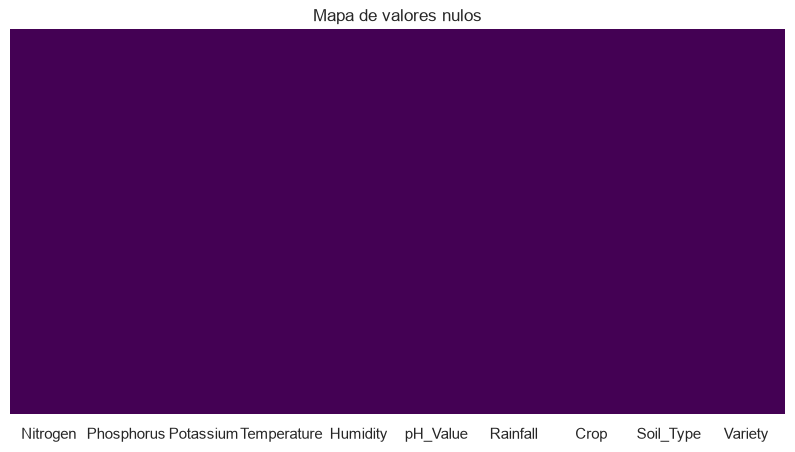

In [5]:
# Mapa de calor de valores nulos (útil si hay columnas con nulos dispersos)
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores nulos")
plt.show()


In [6]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")


Filas duplicadas: 0


## 3. Estadísticos descriptivos

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Nitrogen,20000.0,77.216965,41.857663,5.006013,40.459715,77.573159,113.055595,149.998785
Phosphorus,20000.0,47.482070,24.587506,5.000483,26.225044,47.469579,68.625556,89.999086
Potassium,20000.0,55.162956,25.969091,10.000672,32.641905,55.248133,77.690183,99.996480
Temperature,20000.0,27.420717,10.010144,10.003760,18.880888,27.366450,35.997484,44.997407
Humidity,20000.0,64.897753,20.200687,30.002297,47.462026,64.776613,82.310482,99.992346
pH_Value,20000.0,6.496126,1.155750,4.500082,5.497988,6.493812,7.501771,8.499914
Rainfall,20000.0,211.124002,109.724973,20.018991,117.208556,211.263577,305.668849,399.974915


In [8]:
# Columnas categóricas: conteo de valores únicos
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} valores únicos")
    print(df[col].value_counts().head(10))



Crop: 6 valores únicos
Crop
Wheat        3390
Potato       3362
Maize        3352
Tomato       3344
Sugarcane    3284
Rice         3268
Name: count, dtype: int64

Soil_Type: 6 valores únicos
Soil_Type
Silt      3422
Clay      3401
Saline    3365
Sandy     3312
Peaty     3291
Loamy     3209
Name: count, dtype: int64

Variety: 18 valores únicos
Variety
Durum        1162
Russet       1148
Sweet        1141
Roma         1138
Hard Red     1135
Beefsteak    1133
Co 86032     1122
Red          1119
Flint        1108
Basmati      1104
Name: count, dtype: int64


C:\Users\carli\AppData\Local\Temp\ipykernel_2612\465300169.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


## 4. Distribución de variables numéricas

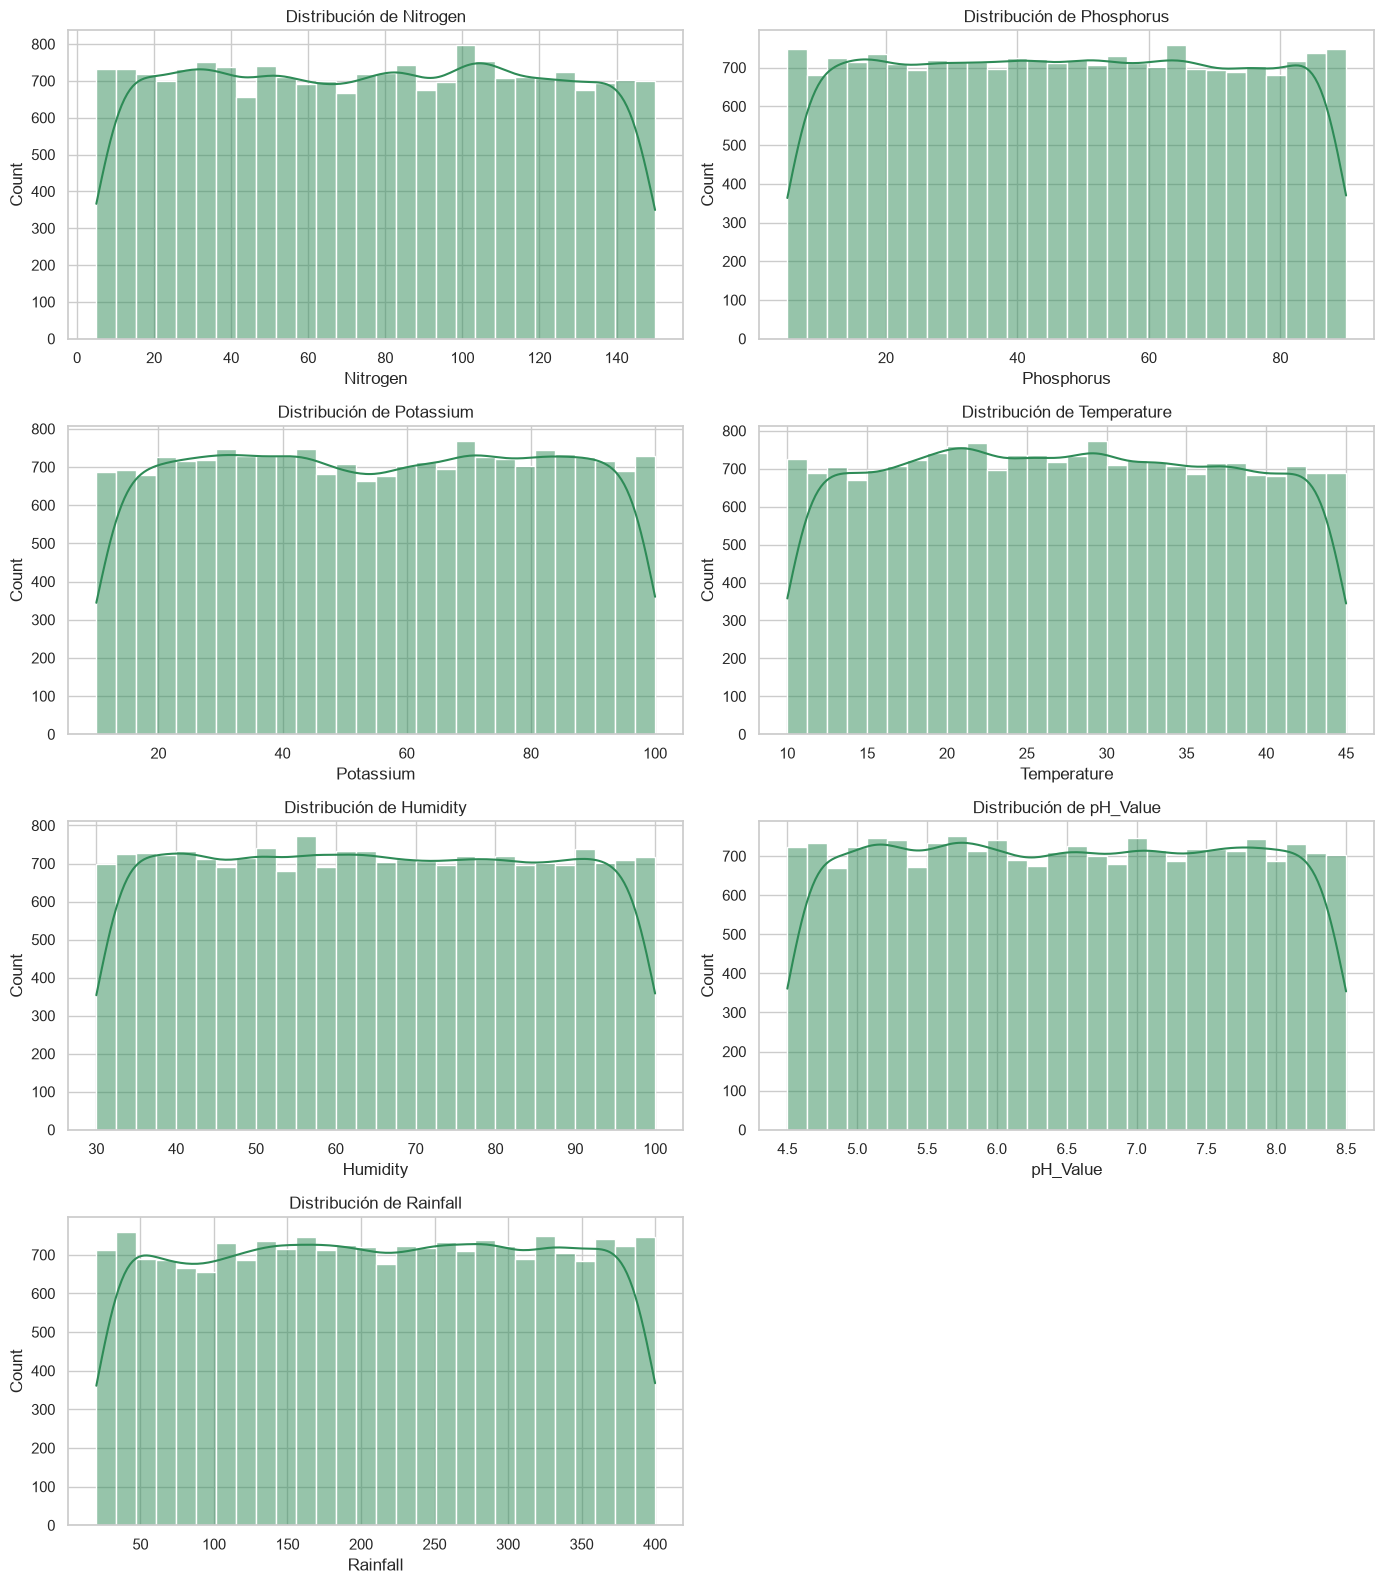

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(nrows=(len(num_cols) + 1) // 2, ncols=2, figsize=(14, 4 * ((len(num_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Distribución de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 5. Detección de valores atípicos (boxplots)

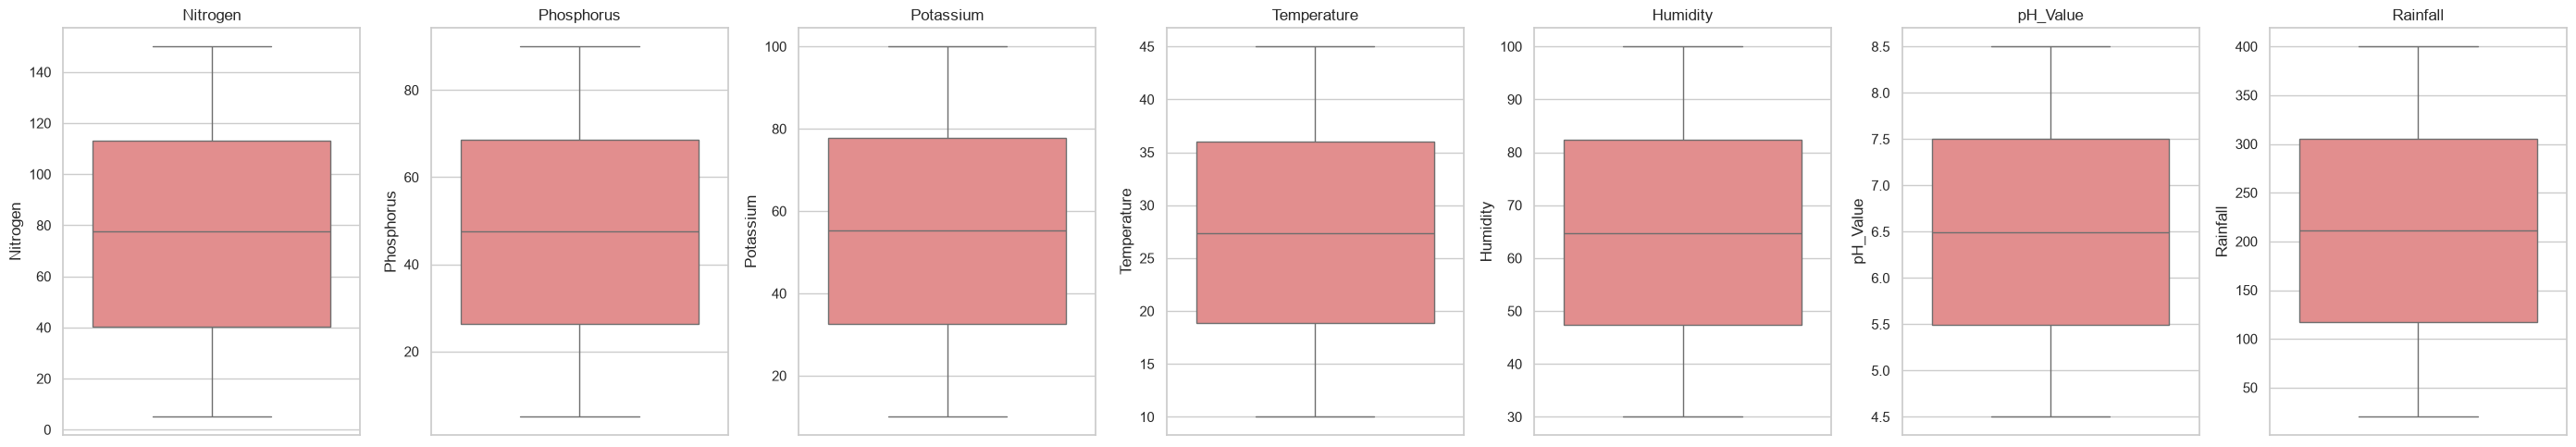

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(4 * len(num_cols), 5))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 6. Matriz de correlación

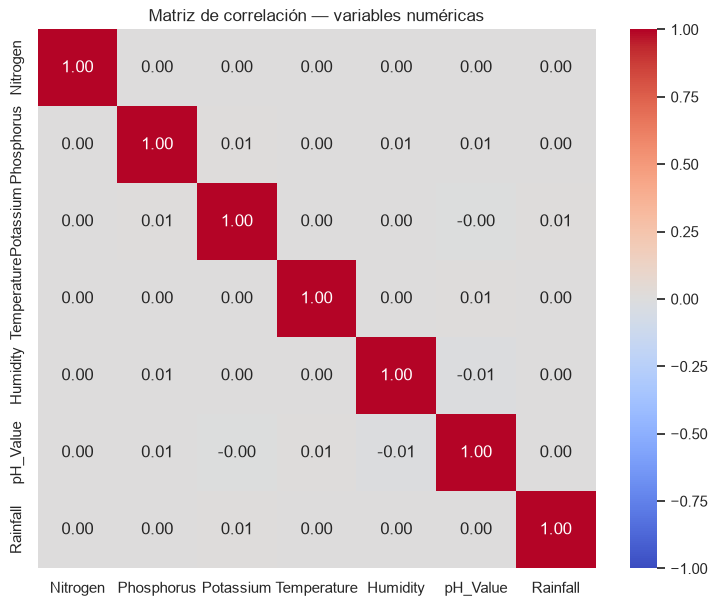

In [11]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación — variables numéricas")
plt.show()


## 7. Relación entre variables (pairplot)

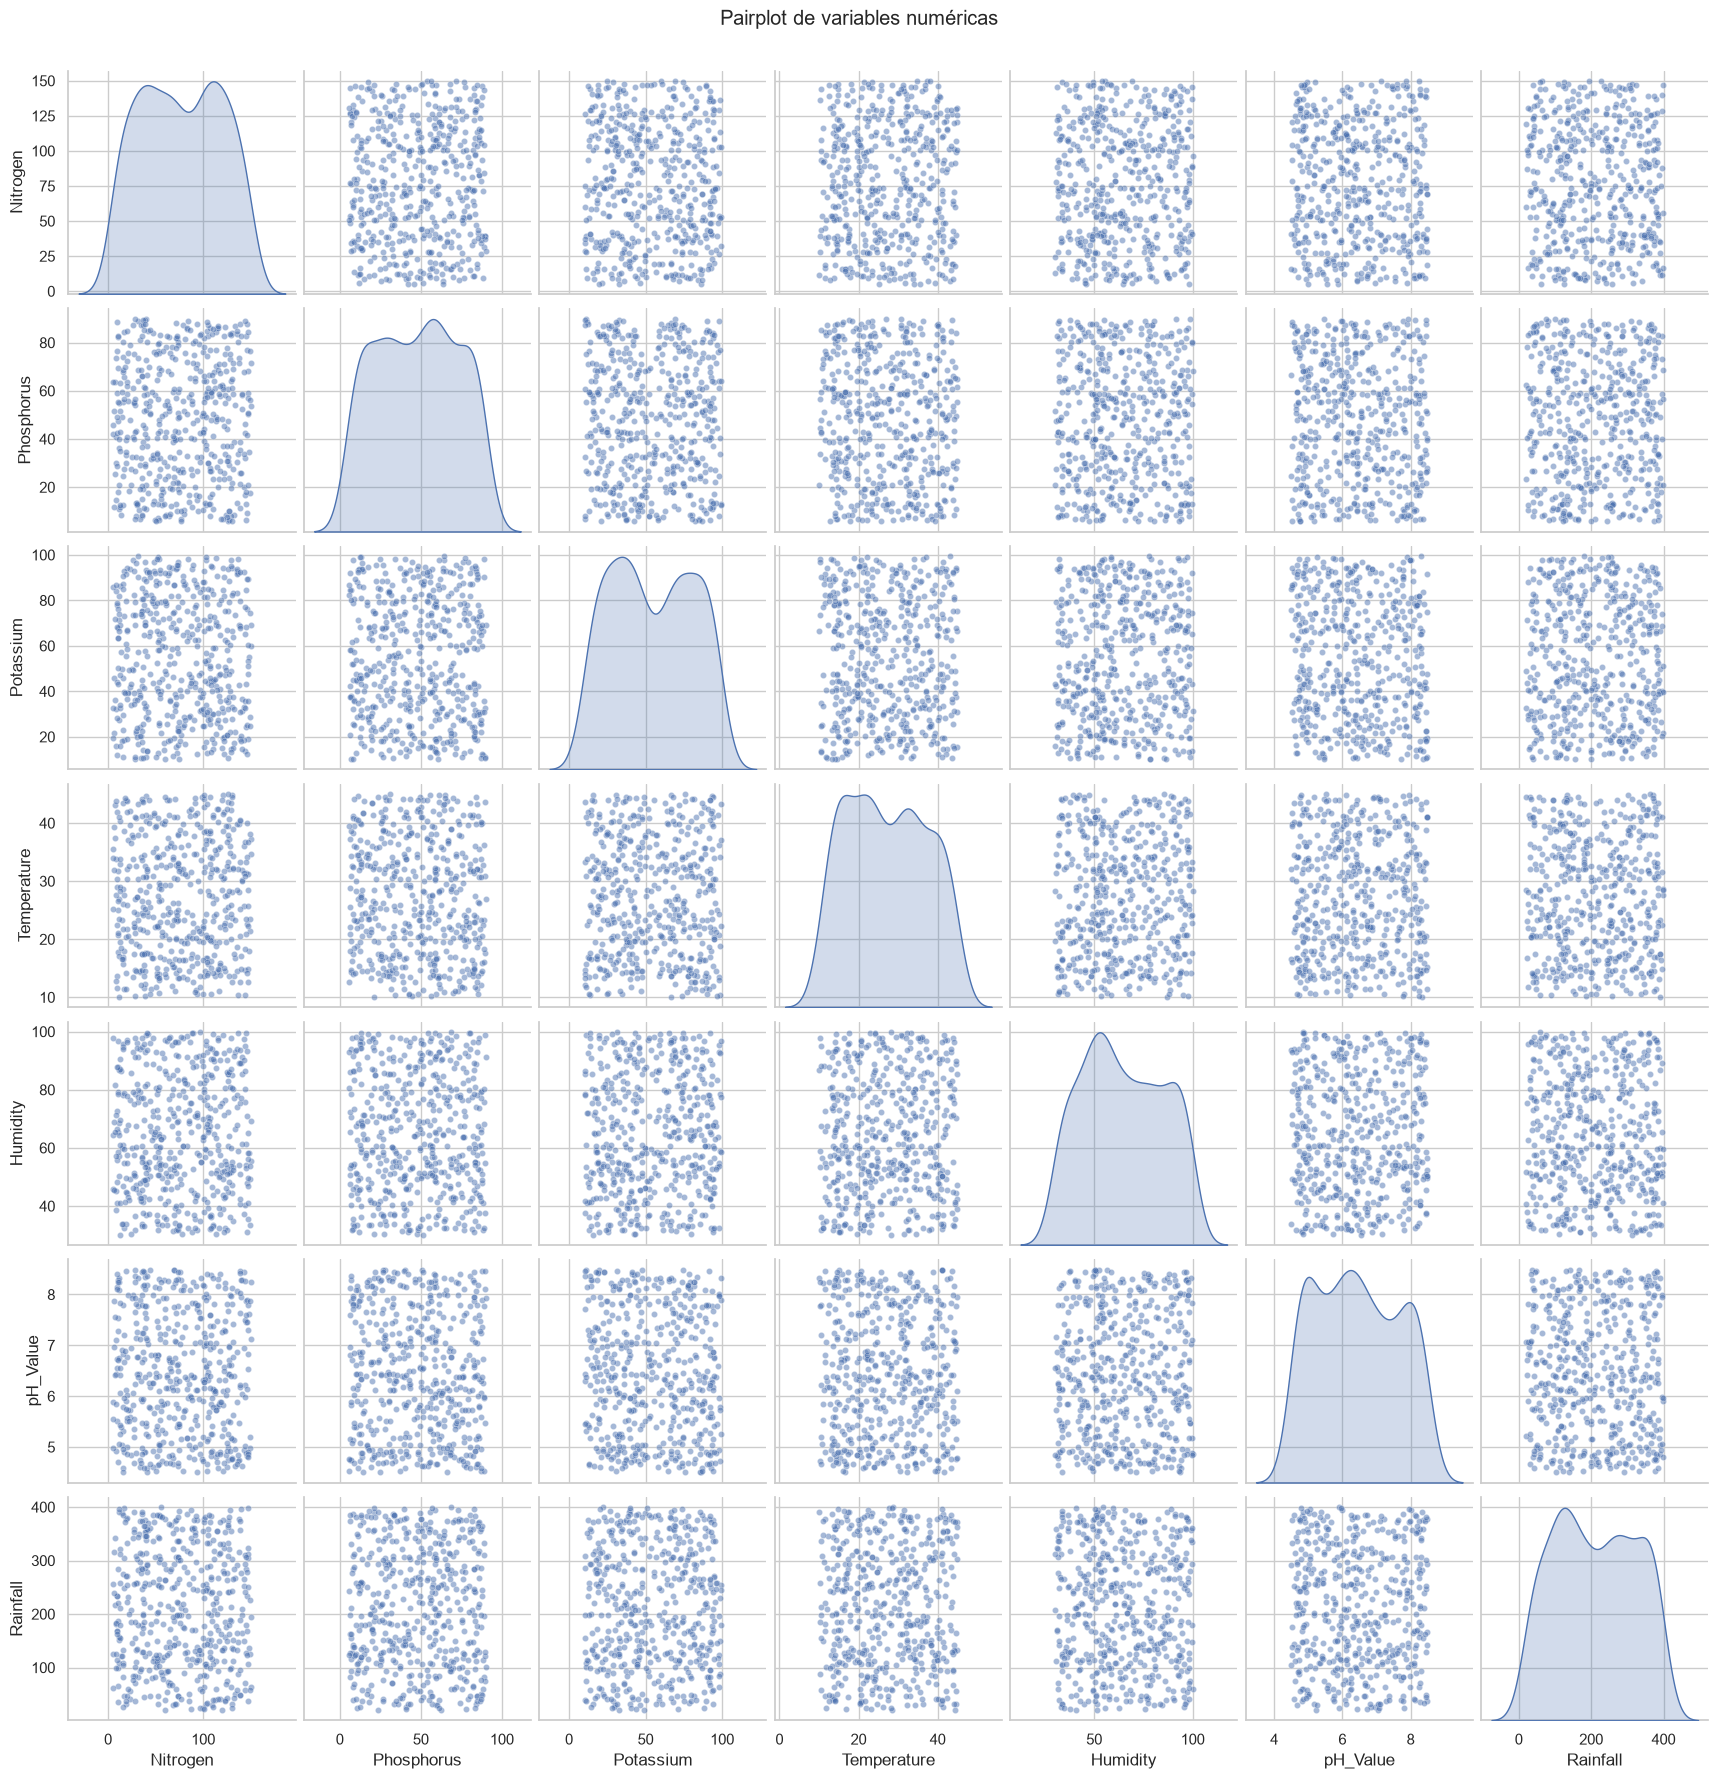

In [12]:
sample = df.sample(min(500, len(df)), random_state=42)  # muestra para que el pairplot no sea muy pesado
sns.pairplot(sample[num_cols], diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()


## 8. Distribución de variables categóricas

C:\Users\carli\AppData\Local\Temp\ipykernel_2612\1683582802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Crop", order=order, palette="viridis")


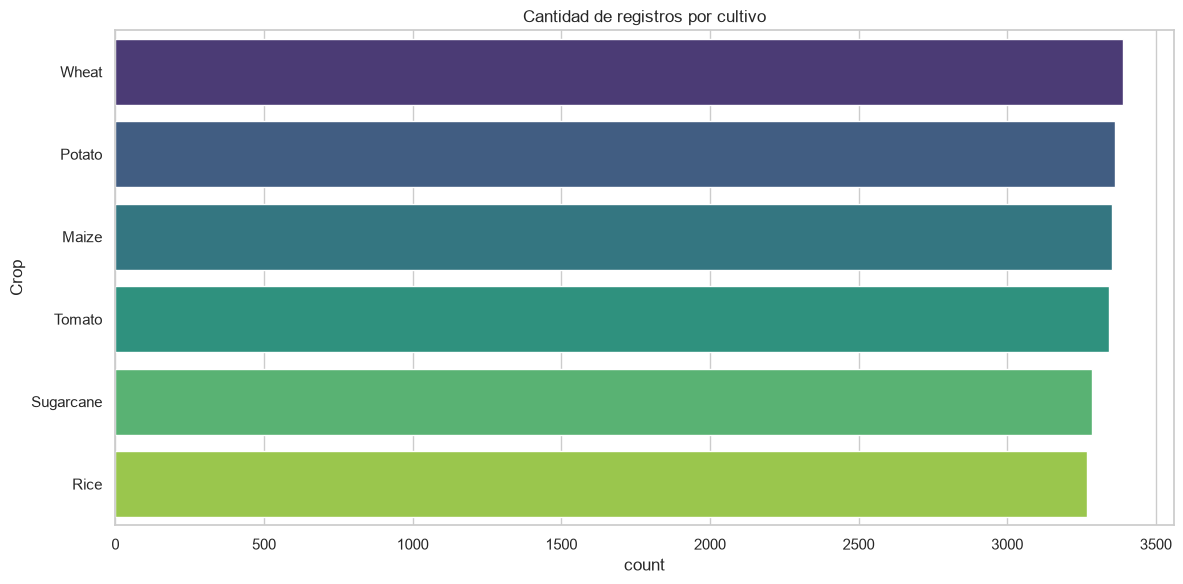

In [13]:
if "Crop" in df.columns:
    plt.figure(figsize=(12, 6))
    order = df["Crop"].value_counts().index
    sns.countplot(data=df, y="Crop", order=order, palette="viridis")
    plt.title("Cantidad de registros por cultivo")
    plt.tight_layout()
    plt.show()


C:\Users\carli\AppData\Local\Temp\ipykernel_2612\377550386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Soil_Type", order=df["Soil_Type"].value_counts().index, palette="crest")


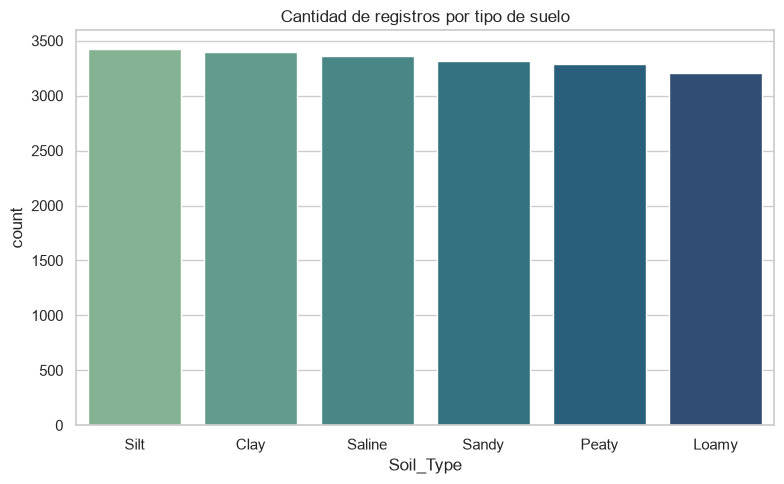

In [14]:
if "Soil_Type" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x="Soil_Type", order=df["Soil_Type"].value_counts().index, palette="crest")
    plt.title("Cantidad de registros por tipo de suelo")
    plt.tight_layout()
    plt.show()


## 9. Conclusiones preliminares del EDA

- **Valores nulos**: No hay valores nulos en el dataset.
- **Filas duplicadas**: No hay filas duplicadas.
- **Atípicos (Outliers)**: Dependiendo de los boxplots, pero en base a la inspección estadística, se sugiere analizar a fondo variables como Rainfall o Temperature que pueden tener valores extremos.
- **Correlación fuerte (>0.6 o <-0.6)**: No hay pares con correlación > 0.6 o < -0.6.
- **Balance del dataset**: 
  - Top cultivos (proporción): {'Wheat': 0.1695, 'Potato': 0.1681, 'Maize': 0.1676}
  - Top tipos de suelo (proporción): {'Silt': 0.1711, 'Clay': 0.17005, 'Saline': 0.16825}
  - Conclusión: El dataset parece tener cierto desbalance que debe ser considerado.
